What is the starting location called? ocean(start)
What would you like to do?
 1. move.
 2. add or remove a room adjacent to the current room.
 3. List rooms and show progress. 
 4. Shorthand mode.
 5. to quit and to save image.
 4



To use this, you can "add or rem [name] [direction] [label, if using addl or rem]"
you can move somewhere with "move to [room name]" or "move [direction] [optional-n times]" or with "move [room number]"
You can list the rooms with "list"
You can add a solitary blue or red room with "addb or addr [name]"
And you can exit with "q" or "quit".





> add oddly shaped island north

> move north 3

> addb oddly shaped island

> add clown cove east

> move west

> add vendor for bananas north

> move west

> move east

> move south

> add house west

> add dining room north

> move south

> add basement down

> add murder room north

> move south

> add clown corner west

> add ball pit down

> add secret north

> move south

> add outside land west

> list




0. ocean(start)
1. oddly shaped island
2. clown cove
3. vendor for bananas
4. house
5. dining room
6. basement
7. murder room
8. clown corner
9. ball pit
10. secret
11. outside land



> move to ocean(start)


You are making rooms for ocean(start) 



> add regularly shaped island east

> move east 3

> addb regularly shaped island

> add hut north

> move south

> add vendor for coconuts east

> move west

> add pirate cove south

> move west

> add shore west

> q
What would you like to do?
 1. move.
 2. add or remove a room adjacent to the current room.
 3. List rooms and show progress. 
 4. Shorthand mode.
 5. to quit and to save image.
 5


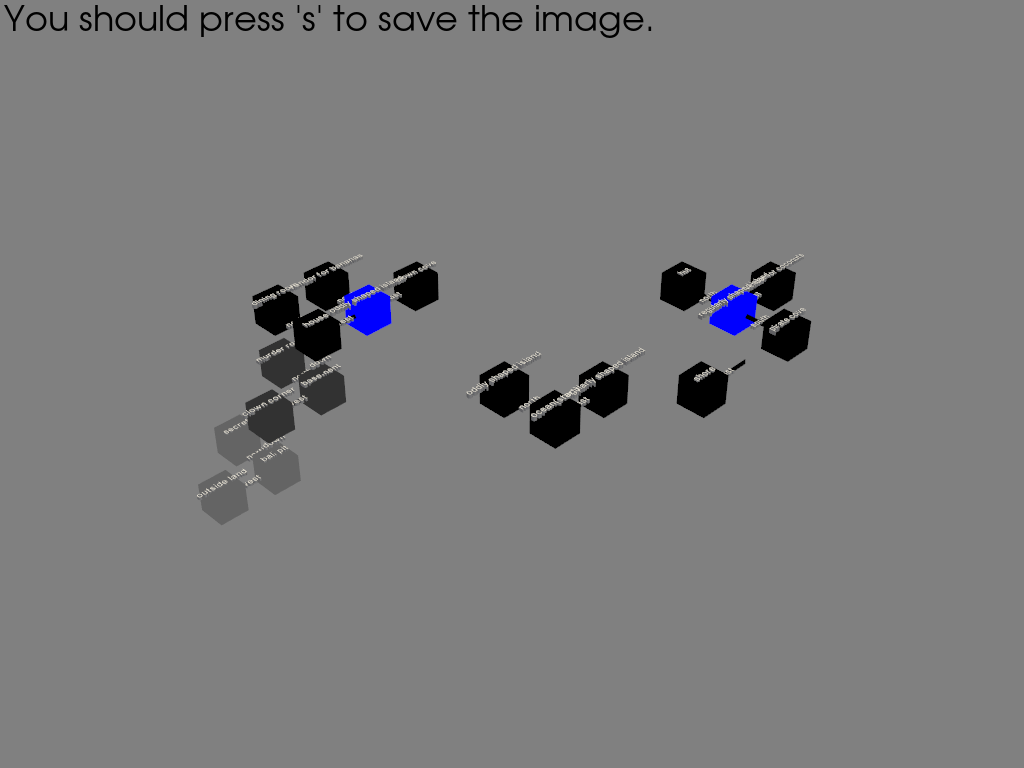

In [28]:
import pyvista as pv
import appdirs
import PIL
class Mapping:
    def __init__(self, geometry):
        self.geometry = geometry
        self.coords = [geometry//2,geometry//2, geometry//2]
        self.rooms = {}
    def addRoom(self, name, direction, label, colour):
        if direction=="alone":
            #checks if the room should be unconnected or not
            Mapping.drawRoom(self.coords, name, colour)
            self.rooms[name.strip().lower()] = self.coords
            return
        self.move("none", direction)
        depth = (5*(self.geometry//2 - self.coords[2]))%200
        self.rooms[name.strip().lower()] = self.coords
        if colour == "black":
            Mapping.drawRoom(self.coords, name, (depth, depth, depth))
            Mapping.drawLine(self.coords, direction, (depth, depth, depth))
            if not label=="none":
                Mapping.addLabel(self.coords, direction, label, colour)
            return
        else:
            Mapping.drawRoom(self.coords, name, colour)
            Mapping.drawLine(self.coords, direction, colour)
        if not label=="none":
            Mapping.addLabel(self.coords, direction, label, colour)
    def move(self, destination, direction):
        if not destination == "none":
            #checks if there is a destination
            if destination[0] in "1234567890":
                #checks if you are using the numerical location
                for num, name in enumerate(self.rooms.keys()):
                    if num == int(destination):
                        self.coords=self.rooms[name]
                        return
            if destination in self.rooms.keys():
                #checks if you input a name for a location
                self.coords=self.rooms[destination]
                return
            else:
                print("\nYou input a non-existant room")
                return
        x = self.coords[0]
        y = self.coords[1]
        z = self.coords[2]
        if(direction == "north"):
            self.coords = [x, y+10, z]
        if(direction == "south"):
            self.coords = [x, y-10, z]
        if(direction == "east"):
            self.coords = [x+10, y, z]
        if(direction == "west"):
            self.coords = [x-10, y, z]
        if(direction == "north-west"):
            self.coords = [x-10,y+10,z]
        if(direction == "north-east"):
            self.coords = [x+10, y+10, z]
        if(direction == "south-west"):
            self.coords = [x-10, y-10, z]
        if(direction == "south-east"):
            self.coords = [x+10, y-10, z]
        if(direction == "down"):
            self.coords = [x, y, z-10]
        if(direction == "up"):
            self.coords = [x , y, z+10]
    @staticmethod
    def addLabel(coords, direction, text, colour):
        #this labels the line
        x=coords[0]
        y=coords[1]
        z=coords[2]
        if direction == "north":
            text_mesh = pv.Text3D(text, center=(x,y-5,z))
        if direction == "south":
            text_mesh = pv.Text3D(text, center=(x,y+5,z))
        if direction == "east":
            text_mesh = pv.Text3D(text, center=(x-5,y,z))
        if direction == "west":
            text_mesh = pv.Text3D(text, center=(x+5,y,z))
        if direction == "north-west":
            text_mesh = pv.Text3D(text, center=(x+5,y-5,z))
        if direction == "north-east":
            text_mesh = pv.Text3D(text, center=(x-5,y-5,z))
        if direction == "south-west":
            text_mesh = pv.Text3D(text, center=(x+5,y+5,z))
        if direction == "south-east":
            text_mesh = pv.Text3D(text, center=(x-5,y+5,z))
        if direction == "down":
            text_mesh = pv.Text3D(text, center=(x,y,z+5))
        if direction == "up":
            text_mesh = pv.Text3D(text, center=(x,y,z-5))
        plotter.add_mesh(text_mesh, color="white")
    @staticmethod
    def drawRoom(coords, text, colour):
        x=coords[0]
        y=coords[1]
        z=coords[2]
        mesh = pv.Cube(center=(x,y,z), x_length=5, y_length=5, z_length=5)
        plotter.add_mesh(mesh, color=colour, lighting=False)
        text_mesh = pv.Text3D(text, center=(x,y,z+2.5))
        plotter.add_mesh(text_mesh, color="white")
    @staticmethod
    def drawLine(coords, direction, colour):
        x=coords[0]
        y=coords[1]
        z=coords[2]
        if direction == "north":
            mesh = pv.Line((x,y,z),(x,y-10,z))
        if direction == "south":
            mesh = pv.Line((x,y,z),(x,y+10,z))
        if direction == "east":
            mesh = pv.Line((x,y,z),(x-10,y,z))
        if direction == "west":
            mesh = pv.Line((x,y,z),(x+10,y,z))
        if direction == "north-west":
            mesh = pv.Line((x,y,z),(x+10,y-10,z))
        if direction == "north-east":
            mesh = pv.Line((x,y,z),(x-10,y-10,z))
        if direction == "south-west":
            mesh = pv.Line((x,y,z),(x+10,y+10,z))
        if direction == "south-east":
            mesh = pv.Line((x,y,z),(x-10,y+10,z))
        if direction == "down":
            mesh = pv.Line((x,y,z),(x,y,z+10))
        if direction == "up":
            mesh = pv.Line((x,y,z),(x,y,z-10))
        plotter.add_mesh(mesh, color=colour, line_width=5)
           
def save():
    plotter.view_isometric()
    plotter.screenshot("isometric.png")
    plotter.export_gltf("for3dViewingSoftware.glb")
    plotter.view_xy()
    plotter.screenshot("top-down.png")
    frames = 180
    plotter.open_gif("rotating_file.gif", fps=12, mode="V")
    angle_per_frame = 360/frames
    for i in range(frames):
        plotter.view_isometric()
        plotter.camera.azimuth=i*angle_per_frame
        plotter.render()
        plotter.write_frame()
    plotter.close()
    return

    
#change this line to alter the image size
geometry = 1000
plotter = pv.Plotter()
plotter.set_background("grey")
card = Mapping(geometry)
name = input("What is the starting location called?")
card.addRoom(name, "alone", "none", "black")
camera = plotter.camera
camera.azimuth=180
while True:
    option = input("What would you like to do?"+
                   "\n 1. move."+
                   "\n 2. add or remove a room adjacent to the current room."+
                   "\n 3. List rooms and show progress. "+
                   "\n 4. Shorthand mode."+
                   "\n 5. to quit and to save image.\n")
    if option in "abcdefghijklmnopqrstuvwxyz":
        print("You input an invalid option")
    else:
        match int(option):
            case 1:
                #Move to direction
                option = input("\nDo you want to 1. go somewhere, or 2. move in a direction")
                if option in "abcdefghijklmnopqrstuvwxyz":
                    print("You input an invalid option")
                else:
                    match int(option):
                        case 1:
                            #changing the current room
                            destination = input("Where do you want to go?")
                            card.move(destination, "random")
                            print(f"\nYou are now making rooms for {destination}")
                        case 2:
                            #moving in a direction
                            direction = input("What is the direction you want to move?")
                            card.move("none", direction)
                        case _:
                            print("You entered an invalid input")
            case 2:
                #add adjacent room
                name = input("What is the next room called?")
                direction = input("What is the direction of this room?")
                label = input("What shall the line's label be? If you don't want it, type none")
                delete = input("Are you deleting this room? no or yes.")
                if delete == "yes":
                    card.addRoom(name, direction, label, "white")
                elif delete == "no":
                    card.addRoom(name, direction, label, "black")
            case 3:
                #list rooms and show image
                for num, room in enumerate(card.rooms.keys()):
                    print("\n")
                    print(f"{num}. {room}")
                plotter.show()
            case 4:
                #shorthand mode, lets you type in commands instead of going through the menu.
                print("\nTo use this, you can \"add or rem [name] [direction] [label, if using addl or rem]\""+
                      "\nyou can move somewhere with \"move to [room name]\" or \"move [direction] [optional-n times]\" or with \"move [room number]\""+
                      "\nYou can list the rooms with \"list\""+
                      "\nYou can add a solitary blue or red room with \"addb or addr [name]\"\n"+
                      "And you can exit with \"q\" or \"quit\".\n\n")
                while True:
                    commands = input("\n>")
                    commands = commands.strip().lower()
                    split = commands.split()
                    
                    if(len(split) == 1):
                        if(split[0] == "list"):
                            #lists all the rooms
                            print("\n")
                            for num, room in enumerate(card.rooms.keys()):
                                print(f"{num}. {room}")
                        if("quit" in split or "q" in split):
                            break
                        
                        if("show" in split):
                            plotter.show()
                    if(len(split) >= 2):
                        if(split[0] == "move" and split[1] == "to" and len(split) >= 3):
                            #puts you in the room you specify
                            name = ""
                            for item in split[2:]:
                                name += item + " "
                            card.move(name.strip(), "random")
                            print(f"You are making rooms for {name}")
                        if(split[0] == "move" and len(split)==2):
                            #makes you move in the direction you specify
                            card.move("none", split[1])
                        if(split[0] == "move" and len(split)==3 and not split[1]=="to"):
                            #to move an n number of times
                            for x in range(int(split[2])):
                                card.move("none", split[1])
                        if(split[0] == "add" and len(split)>=3):
                            #adds a room with the direction as the label
                            name = ""
                            for item in split[1:-1]:
                                name += item + " "
                            card.addRoom(name.strip(), split[-1], split[-1], "black")
                        if(split[0] == "addl" and len(split)>=4):
                            #adds a room with a unique label
                            name = ""
                            for item in split[1:-2]:
                                name += item + " "
                            card.addRoom(name.strip(), split[-2], split[-1], "black")
                        if(split[0] == "addb" and len(split)>=2):
                            #adds a blue room, represents teleportation
                            name = ""
                            for item in split[1:]:
                                name += item + " "
                            card.addRoom(name.strip(), "alone", "none", "blue")
                        if(split[0] == "addr" and len(split)>=2):
                            #adds a red room, represents ending.
                            name = ""
                            for item in split[1:]:
                                name += item + " "
                            card.addRoom(name.strip(), "alone", "none", "red")
                        if(split[0] == "rem" and len(split)>=4):
                            name = ""
                            for item in split[1:-2]:
                                name+= item + " "
                            card.addRoom(name.strip(), split[-2], split[-1], "white")
            case 5:
                #exit the program
                break
            case _:
                print("You input an invalid value")
pv.OFF_SCREEN=True
pv.set_jupyter_backend("static") 
#gif
plotter.view_isometric()
camera.azimuth=180
plotter.add_key_event('s', save)
plotter.add_text("You should press 's' to save the image.")
plotter.show()
plotter.screenshot("maps/isometric.png")
plotter.export_gltf("maps/for3dViewingSoftware.glb")
plotter.view_xy()
plotter.screenshot("maps/top-down.png")
frames = 180
angle_per_frame = 360/frames
plotter.open_gif("rotating_file.gif", fps=12, mode="V")
for i in range(frames):
    plotter.view_isometric()
    plotter.camera.azimuth=i*angle_per_frame
    plotter.render()
    plotter.write_frame()
plotter.close()